# YAFS Simulation Trace Analysis

This notebook analyzes the `sim_trace.csv` file generated by the YAFS simulation. It focuses on:
- **Latency Analysis**: End-to-end delay of messages.
- **Service Time**: Processing time within modules.
- **Traffic Distribution**: Message counts per application and module.
- **Topology Flow**: Communication patterns between Fog and Cloud nodes.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path

# Set plot style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Load and Inspect Data
Load the CSV file and check the structure.

In [ ]:
# Load the dataset
# Update to the specific results file generated by the tutorial
file_path = 'resultados/fog2-middle8-end31-custom_proposed_by_felipe-sim_trace.csv'
df = pd.read_csv(file_path)

# Display first rows
display(df.head())

# Check info
print(df.info())

,id,type,app,module,message,DES.src,DES.dst,TOPO.src,TOPO.dst,TOPO.srcLabel,TOPO.dstLabel,module.src,service,time_in,time_out,time_emit,time_reception
0,1,COMP_M,Application-1,Application-1-Service,M_Req,2,1,12,1,Application-1-Sensor,Fog-0,Application-1-Sensor,0.118850,121.811965,121.930814,100.000000,121.811965
1,1,COMP_M,Application-1,Application-1-Sensor,M_Resp,1,2,1,12,Fog-0,Application-1-Sensor,Application-1-Service,0.014347,143.742779,143.757126,121.930814,143.742779
2,2,COMP_M,Application-1,Application-1-Service,M_Req,2,1,12,1,Application-1-Sensor,Fog-0,Application-1-Sensor,0.142494,221.811965,221.954459,200.000000,221.811965
3,2,COMP_M,Application-1,Application-1-Sensor,M_Resp,1,2,1,12,Fog-0,Application-1-Sensor,Application-1-Service,0.018405,243.766424,243.784828,221.954459,243.766424
4,7,COMP_M,Application-3,Application-3-Service,M_Req,11,10,16,2,Application-3-Sensor,Fog-1,Application-3-Sensor,0.099637,527.732373,527.832009,500.000000,527.732373


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              6 non-null      int64  
 1   type            6 non-null      object 
 2   app             6 non-null      object 
 3   module          6 non-null      object 
 4   message         6 non-null      object 
 5   DES.src         6 non-null      int64  
 6   DES.dst         6 non-null      int64  
 7   TOPO.src        6 non-null      int64  
 8   TOPO.dst        6 non-null      int64  
 9   TOPO.srcLabel   6 non-null      object 
 10  TOPO.dstLabel   6 non-null      object 
 11  module.src      6 non-null      object 
 12  service         6 non-null      float64
 13  time_in         6 non-null      float64
 14  time_out        6 non-null      float64
 15  time_emit       6 non-null      float64
 16  time_reception  6 non-null      float64
dtypes: float64(5), int64(5), object(7)
memo

## 2. Data Preprocessing
Calculate key metrics:
- **Latency**: `service`
- **Service Time**: `time_out - time_in`
- **Network/Wait Time**: `Latency - Service Time`

In [3]:
# Calculate Latency (Convert to ms)
df['Latency'] = df['service'] * 1000

# Calculate Service Time (Processing Duration) (Convert to ms)
df['Service_Time'] = (df['time_out'] - df['time_in']) * 1000

# Calculate Network + Wait Time
df['Network_Wait_Time'] = df['Latency'] - df['Service_Time']

# Create a combined label for Application and Node
df['App_Node'] = df['app'] + ' (' + df['TOPO.dstLabel'] + ')'

# Display summary stats for these new metrics
df[['Latency', 'Service_Time', 'Network_Wait_Time']].describe()

,Latency,Service_Time,Network_Wait_Time
count,6.000000,6.000000,6.000000e+00
mean,68.908838,68.908838,-2.722267e-12
std,57.965774,57.965774,1.584089e-11
min,14.346966,14.346966,-2.790657e-11
25%,18.733787,18.733787,-8.675727e-12
50%,59.678893,59.678893,-2.115641e-12
75%,114.046338,114.046338,5.572875e-12
max,142.494037,142.494037,1.853095e-11


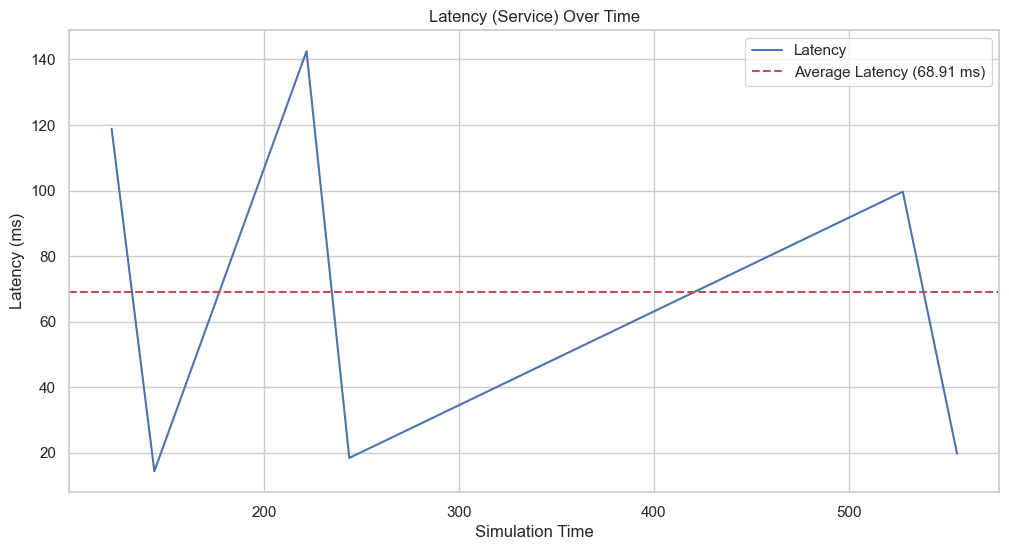

In [4]:
# Simple Line Plot: Latency (Service) over Time
plt.figure(figsize=(12, 6))
sns.lineplot(x='time_reception', y='Latency', data=df, label='Latency')

# Calculate and plot average
mean_latency = df['Latency'].mean()
plt.axhline(y=mean_latency, color='r', linestyle='--', label=f'Average Latency ({mean_latency:.2f} ms)')

plt.title('Latency (Service) Over Time')
plt.xlabel('Simulation Time')
plt.ylabel('Latency (ms)')
plt.legend()
plt.show()

## 3. Descriptive Statistics
Analyze the frequency of applications, modules, and message types.

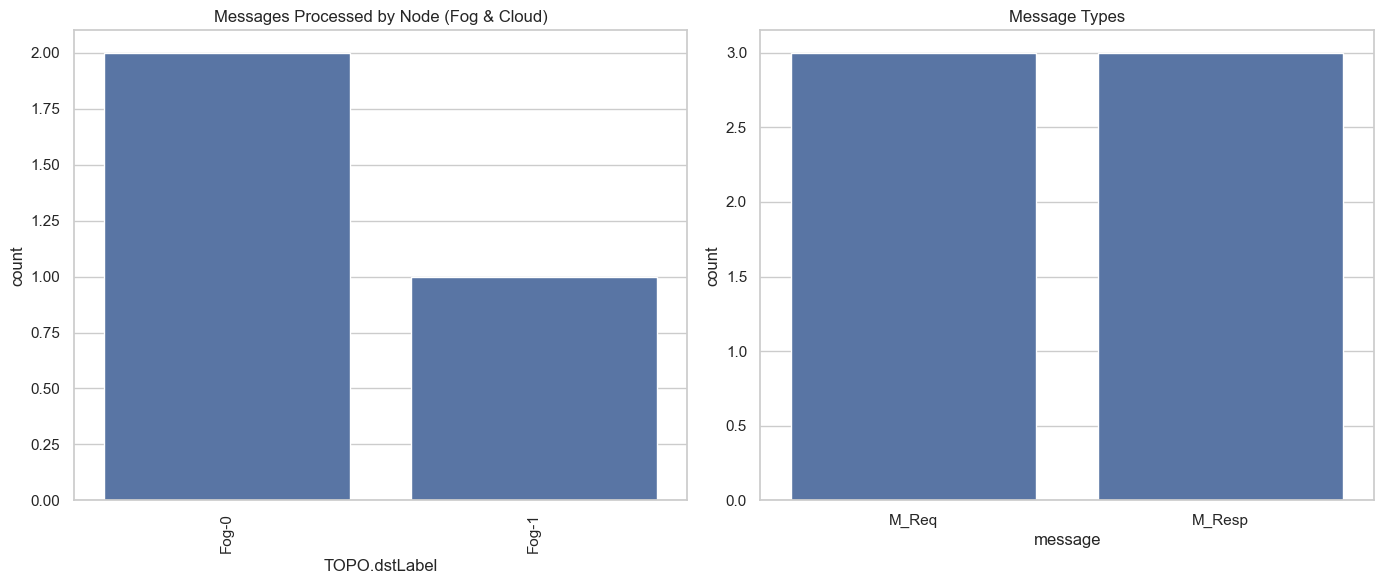

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. Messages Processed by Node (Physical Node only)
# Filter for M_Req messages to show only Fog/Cloud nodes (Service providers)
# M_Resp messages go back to Sensors (Users), so we exclude them here.
df_fog_cloud = df[df['message'] == 'M_Req']
sns.countplot(x='TOPO.dstLabel', data=df_fog_cloud, ax=axes[0])
axes[0].set_title('Messages Processed by Node (Fog & Cloud)')
axes[0].tick_params(axis='x', rotation=90)

# 2. Message Types
# We use the 'message' column to distinguish M_Req, M_Resp, M_Act
sns.countplot(x='message', data=df, ax=axes[1])
axes[1].set_title('Message Types')

plt.tight_layout()
plt.show()

## 4. Latency Analysis
Visualize the distribution of latency and compare it across applications.

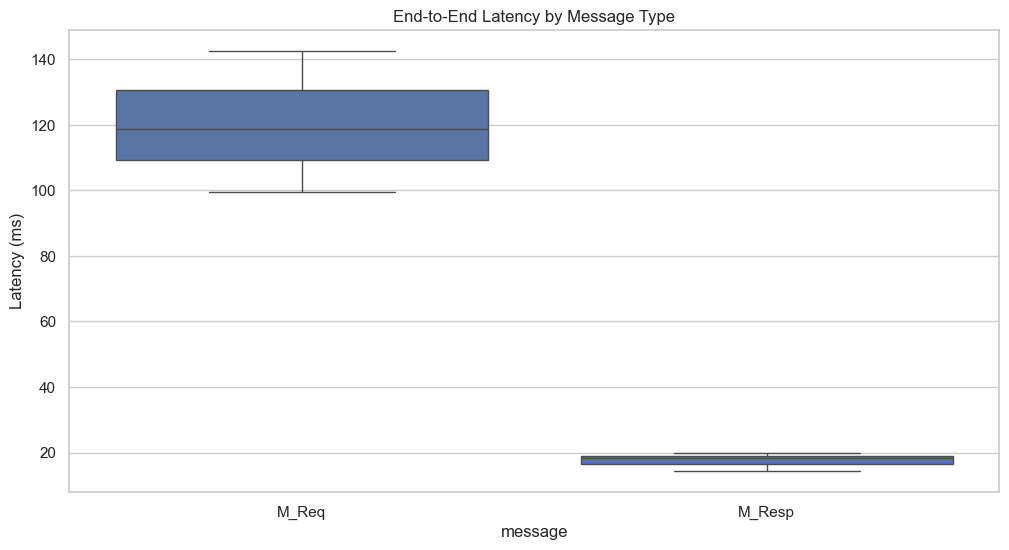

In [6]:
# Latency Distribution by Message Type
plt.figure(figsize=(12, 6))
sns.boxplot(x='message', y='Latency', data=df)
plt.title('End-to-End Latency by Message Type')
plt.ylabel('Latency (ms)')
plt.show()

## 5. Service Time Analysis
Compare processing times across different nodes (Fog vs Cloud).

## 6. Traffic Load Over Time
Check if the traffic is constant or bursty.

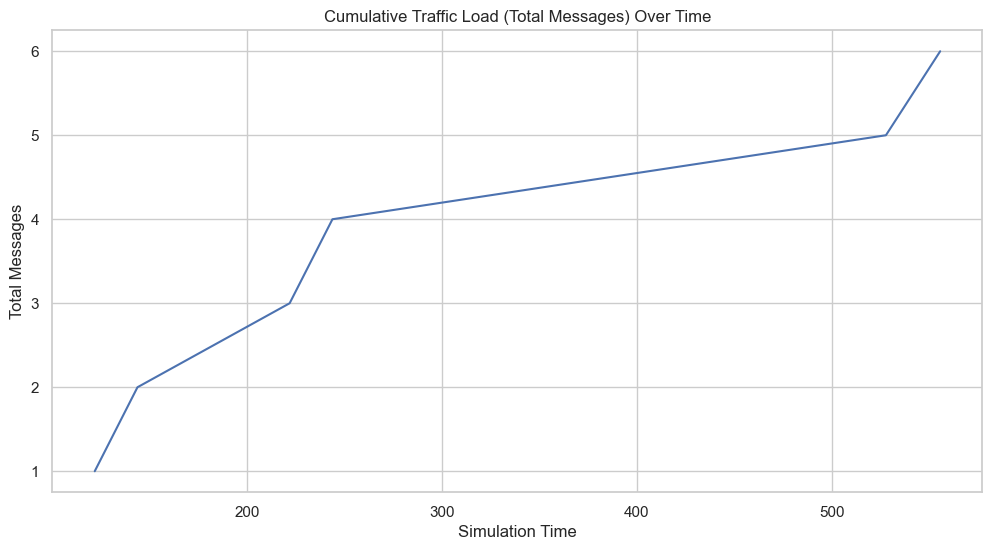

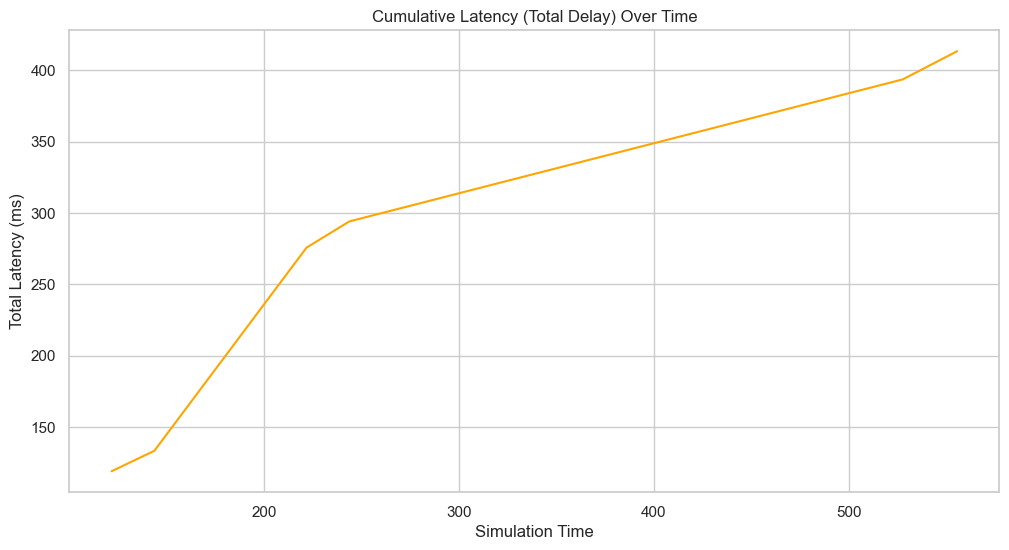

In [7]:
# Sort by time_reception to ensure correct cumulative sum
df_sorted = df.sort_values('time_reception')

# Calculate cumulative sum of messages
df_sorted['cumulative_messages'] = np.arange(1, len(df_sorted) + 1)

# Calculate cumulative sum of latency (in ms)
df_sorted['cumulative_latency'] = (df_sorted['service'] * 1000).cumsum()

# Plot 1: Cumulative Messages
plt.figure(figsize=(12, 6))
sns.lineplot(x='time_reception', y='cumulative_messages', data=df_sorted)
plt.title('Cumulative Traffic Load (Total Messages) Over Time')
plt.xlabel('Simulation Time')
plt.ylabel('Total Messages')
plt.show()

# Plot 2: Cumulative Latency
plt.figure(figsize=(12, 6))
sns.lineplot(x='time_reception', y='cumulative_latency', data=df_sorted, color='orange')
plt.title('Cumulative Latency (Total Delay) Over Time')
plt.xlabel('Simulation Time')
plt.ylabel('Total Latency (ms)')
plt.show()

## 7. Network Topology Flow
Visualize the communication frequency between different nodes.

In [8]:
# Create a pivot table (crosstab) showing communication frequency
communication_table = pd.crosstab(df['TOPO.srcLabel'], df['TOPO.dstLabel'])

print("Communication Table (Source Node vs Destination Node):")
display(communication_table)

Communication Table (Source Node vs Destination Node):


TOPO.dstLabel,Application-1-Sensor,Application-3-Sensor,Fog-0,Fog-1
TOPO.srcLabel,,,,
Application-1-Sensor,0,0,2,0
Application-3-Sensor,0,0,0,1
Fog-0,2,0,0,0
Fog-1,0,1,0,0


## 8. Conclusion
This notebook provides a comprehensive overview of the simulation results.
- **Latency**: Check the boxplots to see if any application suffers from high latency.
- **Service Time**: Compare Fog vs Cloud nodes to see if Fog nodes are processing faster or if they are overloaded.
- **Traffic**: Ensure the load is distributed as expected and not saturating specific nodes (check the Heatmap).

## 6. Unprocessed Messages Analysis (Congestion/Loss)
Analyze messages that did not complete before the simulation ended. This indicates severe congestion or bottlenecks.

In [9]:
import os

unprocessed_path = 'resultados/unprocessed_messages.csv'

if os.path.exists(unprocessed_path):
    df_unprocessed = pd.read_csv(unprocessed_path)
    
    print(f"Total Unprocessed Messages: {len(df_unprocessed)}")
    
    if len(df_unprocessed) > 0:
        display(df_unprocessed.head())
        
        # 1. Count by Queue Type
        plt.figure(figsize=(8, 5))
        sns.countplot(x='QueueType', data=df_unprocessed)
        plt.title('Unprocessed Messages by Queue Type')
        plt.show()
        
        # 2. Count by Application (Top 20)
        top_stuck_apps = df_unprocessed['App'].value_counts().nlargest(20).index
        df_stuck_top20 = df_unprocessed[df_unprocessed['App'].isin(top_stuck_apps)]
        
        plt.figure(figsize=(12, 6))
        sns.countplot(x='App', data=df_stuck_top20, order=top_stuck_apps)
        plt.title('Stuck Messages by Application (Top 20)')
        plt.xticks(rotation=45, ha='right')
        plt.show()
        
        # 3. Distribution of "Until" time (Projected Completion Time)
        # Filter out N/A values if any
        df_unprocessed['Until'] = pd.to_numeric(df_unprocessed['Until'], errors='coerce')
        
        plt.figure(figsize=(10, 6))
        sns.histplot(df_unprocessed['Until'].dropna(), kde=True, color='red')
        plt.title('Projected Completion Time of Stuck Messages')
        plt.xlabel('Simulation Time')
        plt.show()
        
    else:
        print("No unprocessed messages found. Great!")
else:
    print("unprocessed_messages.csv not found.")

Total Unprocessed Messages: 0
No unprocessed messages found. Great!


## 9. Failures Over Time
Load the failure trace (same basename as `file_path` with `_failure.csv`) and plot how failures accumulate over the simulation.

Loaded failure metrics from resultados/fog2-middle8-end31-latency-sim_trace_failure.csv


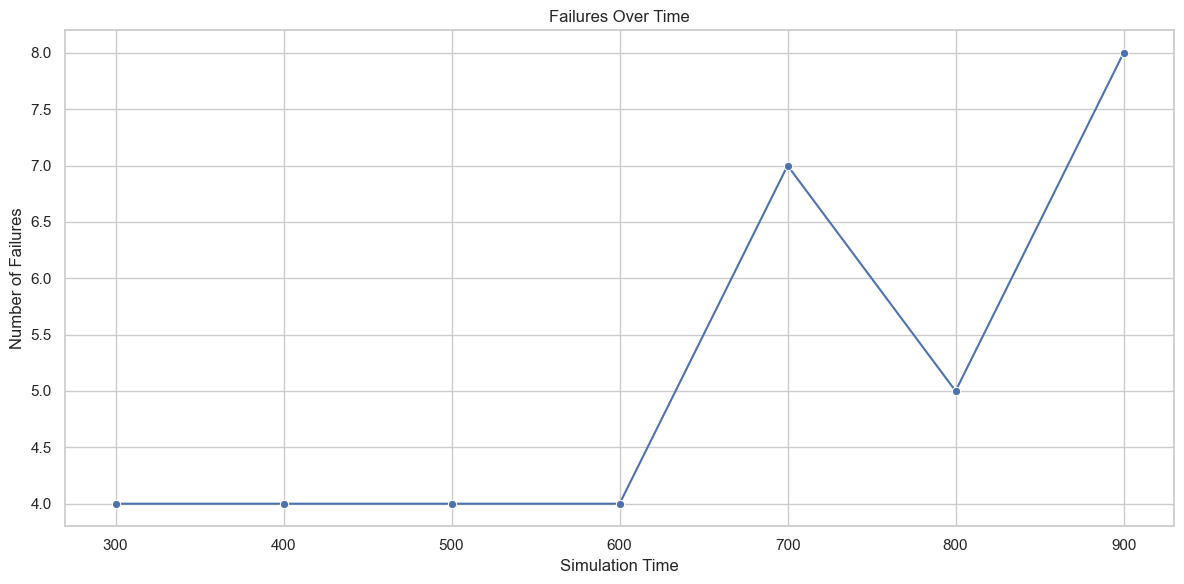

In [10]:
failure_path = Path(file_path).with_name(Path(file_path).stem + "_failure.csv")
df_failure = None

if failure_path.exists():
    df_failure = pd.read_csv(failure_path)
    print(f"Loaded failure metrics from {failure_path}")
else:
    print(f"No failure metrics file found at {failure_path}")

if df_failure is not None:
    time_col = None
    for candidate in ["ctime", "time", "time_reception", "time_emit", "timestamp", "time_in", "time_out", "t"]:
        if candidate in df_failure.columns:
            time_col = candidate
            break

    if time_col is None:
        print("No time-like column found in failure metrics; available columns:", df_failure.columns.tolist())
    else:
        df_failure["time_bin"] = df_failure[time_col].astype(float).round().astype(int)
        failures_over_time = df_failure.groupby("time_bin").size().reset_index(name="failures")
        plt.figure(figsize=(12, 6))
        sns.lineplot(x="time_bin", y="failures", data=failures_over_time, marker="o")
        plt.title("Failures Over Time")
        plt.xlabel("Simulation Time")
        plt.ylabel("Number of Failures")
        plt.tight_layout()
        plt.show()